In [88]:
import pandas as pd
import numpy as np

In [89]:
df = pd.read_csv(
    "/Users/malynnburanawichian/Downloads/Industrials-sector-ESG-and-stock-market-data.csv"
)

In [90]:
df.head()

,Unique_id,Symbol,Company_name,Exchange,gicSector,gicSubindustry,Company_ESG_pulse,ESG_beta,SNP,Sustainalytics,...,52w_change price,52w_change price percent,52w_average volume,Name,Sector,Industry,isin,cusip,Securities_type,Currency_code
0,190179,MMM,3M Company,New York Stock Exchange,Industrials,Industrial Conglomerates,-0.083992,0.010832,67.0,32.2,...,-11.290,-10.83,1648276.0,3M Company Common Stock,Health Care,Medical/Dental Instruments,US88579Y1010,88579Y101,Common Stock,USD
1,205868,JOBS,"51job, Inc",Nasdaq,Industrials,Human Resource & Employment Services,0.776978,-0.203820,89.0,15.2,...,NaN,NaN,NaN,NaN,NaN,NaN,US3168271043,316827104,Common Stock,USD
2,191323,AOS,A. O. Smith Corporation,New York Stock Exchange,Industrials,Building Products,0.251170,0.159637,17.0,25.5,...,19.470,29.49,452457.0,A.O. Smith Corporation Common Stock,Industrials,Industrial Machinery/Components,US8318652091,831865209,Common Stock,USD
3,206373,AAON,"AAON, Inc",Nasdaq,Industrials,Building Products,0.739143,NaN,29.0,NaN,...,-10.145,-10.51,157665.0,NaN,NaN,NaN,US0003602069,000360206,Common Stock,USD
4,190905,AIR,AAR Corp,New York Stock Exchange,Industrials,Aerospace & Defense,0.588800,NaN,NaN,NaN,...,6.670,12.26,74456.0,AAR Corp. Common Stock,Industrials,Aerospace,US0003611052,000361105,Common Stock,USD


In [91]:
df.shape

(705, 31)

In [92]:
df.columns.tolist()

['Unique_id',
 'Symbol',
 'Company_name',
 'Exchange',
 'gicSector',
 'gicSubindustry',
 'Company_ESG_pulse',
 'ESG_beta',
 'SNP',
 'Sustainalytics',
 'MSCI',
 'SNP_normalized',
 'Sustainalytics_normalized',
 'MSCI_normalized',
 'Update_date-ESG_scores',
 'Address',
 'Country',
 'Volume',
 'Market Cap',
 '52w_highest price',
 '52w_lowest price',
 '52w_change price',
 '52w_change price percent',
 '52w_average volume',
 'Name',
 'Sector',
 'Industry',
 'isin',
 'cusip',
 'Securities_type',
 'Currency_code']

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unique_id                  705 non-null    int64  
 1   Symbol                     704 non-null    object 
 2   Company_name               705 non-null    object 
 3   Exchange                   705 non-null    object 
 4   gicSector                  705 non-null    object 
 5   gicSubindustry             690 non-null    object 
 6   Company_ESG_pulse          705 non-null    float64
 7   ESG_beta                   146 non-null    float64
 8   SNP                        321 non-null    float64
 9   Sustainalytics             150 non-null    float64
 10  MSCI                       130 non-null    object 
 11  SNP_normalized             145 non-null    float64
 12  Sustainalytics_normalized  150 non-null    float64
 13  MSCI_normalized            130 non-null    float64

In [94]:
df.isnull().sum()

Unique_id                      0
Symbol                         1
Company_name                   0
Exchange                       0
gicSector                      0
gicSubindustry                15
Company_ESG_pulse              0
ESG_beta                     559
SNP                          384
Sustainalytics               555
MSCI                         575
SNP_normalized               560
Sustainalytics_normalized    555
MSCI_normalized              575
Update_date-ESG_scores         0
Address                        0
Country                      471
Volume                       465
Market Cap                   465
52w_highest price            317
52w_lowest price             317
52w_change price             317
52w_change price percent     317
52w_average volume           317
Name                         465
Sector                       471
Industry                     471
isin                         164
cusip                        164
Securities_type                0
Currency_c

# dataset loaded 
# dataset overviewed ESG and financial market data included
# missing values = stock market data available for 388 companies
# several variables contain missing values

In [95]:
keep_cols = [
    'Company_name',
    'Symbol',
    'gicSubindustry',
    'Company_ESG_pulse',
    'Market Cap',
    'Volume',
    '52w_change price percent'
]

df_clean = df[keep_cols].copy()

In [96]:
df_clean.head()

,Company_name,Symbol,gicSubindustry,Company_ESG_pulse,Market Cap,Volume,52w_change price percent
0,3M Company,MMM,Industrial Conglomerates,-0.083992,5.096457e+10,2024694.0,-10.83
1,"51job, Inc",JOBS,Human Resource & Employment Services,0.776978,NaN,NaN,NaN
2,A. O. Smith Corporation,AOS,Building Products,0.251170,1.256457e+10,552008.0,29.49
3,"AAON, Inc",AAON,Building Products,0.739143,NaN,NaN,-10.51
4,AAR Corp,AIR,Aerospace & Defense,0.588800,2.186558e+09,174582.0,12.26


In [97]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Company_name              705 non-null    object 
 1   Symbol                    704 non-null    object 
 2   gicSubindustry            690 non-null    object 
 3   Company_ESG_pulse         705 non-null    float64
 4   Market Cap                240 non-null    float64
 5   Volume                    240 non-null    float64
 6   52w_change price percent  388 non-null    float64
dtypes: float64(4), object(3)
memory usage: 38.7+ KB


In [98]:
df_clean.isnull().sum()

Company_name                  0
Symbol                        1
gicSubindustry               15
Company_ESG_pulse             0
Market Cap                  465
Volume                      465
52w_change price percent    317
dtype: int64

In [99]:
df_clean.shape

(705, 7)

In [100]:
df_stock = df_clean.dropna(
    subset=['52w_change price percent']
)

In [101]:
df_clean.duplicated().sum()

np.int64(0)

In [102]:
df_clean['gicSubindustry'].isnull().sum()

np.int64(15)

In [103]:
df_clean['Symbol'].isnull().sum()

np.int64(1)

# Kept ESG, stock performance, and industry variables
# # Dropped non-essential identifiers and metadata columns (Unique_id, Address, isin, cusip, Currency_code, Securities_type,Update_date-ESG_scores)
# Created a reduced analytical dataset for analysis

In [104]:
df_clean.duplicated().sum()

np.int64(0)

In [105]:
df_clean.isnull().sum()

Company_name                  0
Symbol                        1
gicSubindustry               15
Company_ESG_pulse             0
Market Cap                  465
Volume                      465
52w_change price percent    317
dtype: int64

In [106]:
df_clean.isnull().sum()

Company_name                  0
Symbol                        1
gicSubindustry               15
Company_ESG_pulse             0
Market Cap                  465
Volume                      465
52w_change price percent    317
dtype: int64

In [107]:
# Remove row with missing symbol
df_clean = df_clean.dropna(subset=['Symbol'])

In [108]:
# Create stock analysis dataset
df_stock = df_clean.dropna(
    subset=['52w_change price percent']
)

# Reviewed missing values in the analytical dataset
# ESG data is complete, while stock market variables contain missing values
# Missing values will be handled based on analysis requirements

In [109]:
df_clean[df_clean['Symbol'].isnull()]

,Company_name,Symbol,gicSubindustry,Company_ESG_pulse,Market Cap,Volume,52w_change price percent


In [110]:
df_stock[['Company_ESG_pulse']].describe()

,Company_ESG_pulse
count,388.000000
mean,0.216133
std,0.392720
min,-0.971600
25%,0.000000
50%,0.251912
75%,0.509118
max,0.995400


In [111]:
df_stock[['52w_change price percent']].describe()

,52w_change price percent
count,388.000000
mean,29.596237
std,87.031630
min,-100.000000
25%,-6.342500
50%,18.350000
75%,52.555000
max,900.000000


In [112]:
df_stock[['Company_ESG_pulse',
          '52w_change price percent']].corr()

,Company_ESG_pulse,52w_change price percent
Company_ESG_pulse,1.000000,0.035148
52w_change price percent,0.035148,1.000000


In [113]:
df_clean['Symbol'].isnull().sum()

np.int64(0)

# ESG pulse 
# Mean: 0.216
# Median: 0.252
# Min: -0.972
# Max: 0.995

# ESG scores are fairly spread out.
# Most companies have slightly positive ESG scores.
# There are both strong ESG leaders and laggards.

# 52 week stock performance 
# Mean: 29.6%
# Median: 18.4%
# Min: -100%
# Max: 900%

# Stock performance varies dramatically.
# Some companies experienced extreme gains.
# The very high maximum (900%) suggests outliers.


# EDA Findings
# ESG scores are broadly distributed across companies
# Stock performance varies significantly, with several extreme outliers
# Correlation between ESG Pulse and stock performance is very weak (0.035)
# Additional analysis is required to identify industry-level patterns

# Initial analysis found almost no relationship between ESG scores and short-term stock performance. This suggests that higher ESG ratings alone do not necessarily lead to higher stock returns.

In [114]:
df_stock.nlargest(
    10,
    'Company_ESG_pulse'
)[['Company_name','gicSubindustry','Company_ESG_pulse']]
# Identified the top ESG-performing companies in the dataset


,Company_name,gicSubindustry,Company_ESG_pulse
331,Highway Holdings Limited,Industrial Machinery,0.995400
219,EVI Industries Inc,Trading Companies & Distributors,0.953800
121,CBAK Energy Technology Inc,Electronic Components,0.937100
346,"Hurco Companies, Inc",Industrial Machinery,0.924067
91,Azek Company Inc,Building Products,0.923342
304,Griffon Corporation,Building Products,0.914050
430,ManpowerGroup Inc,Human Resource & Employment Services,0.900880
243,Espey Mfg. & Electronics Corp,Electrical Components & Equipment,0.899800
63,"Apogee Enterprises, Inc",Building Products,0.880982
41,"Air Transport Services Group, Inc",Air Freight & Logistics,0.877479


In [115]:
df_stock.groupby(
    'gicSubindustry'
)['Company_ESG_pulse'].mean().sort_values(
    ascending=False
).head(10)

# Compared average ESG scores across industrial subindustries

gicSubindustry
Electronic Components                    0.937100
Building Products & Equipment            0.577030
Construction Machinery & Heavy Trucks    0.478112
Heavy Electrical Equipment               0.461216
Building Products                        0.423180
Agricultural & Farm Machinery            0.405088
Trading Companies & Distributors         0.347512
Office Services & Supplies               0.329138
Diversified Support Services             0.321154
Electrical Components & Equipment        0.280018
Name: Company_ESG_pulse, dtype: float64

In [116]:
df_stock.groupby(
    'gicSubindustry'
)['Company_ESG_pulse'].mean().sort_values().head(10)

# Identified subindustries with the lowest average ESG scores

gicSubindustry
Marine Ports & Services               -0.671661
Airport Services                      -0.056239
Trucking                              -0.051395
Railroads                             -0.034574
Highways & Railtracks                  0.000000
Electronic Manufacturing Services      0.000000
Industrial Conglomerates               0.015317
Environmental & Facilities Services    0.034501
Research & Consulting Services         0.064647
Airlines                               0.097814
Name: Company_ESG_pulse, dtype: float64

In [117]:
df_stock['ESG_Group'] = pd.qcut(
    df_stock['Company_ESG_pulse'],
    q=3,
    labels=['Low ESG','Medium ESG','High ESG']
)

# Grouped companies into low, medium, and high ESG categories

/var/folders/k6/v97pgdpx3ss61r9kylwxkkzh0000gn/T/ipykernel_16589/1983160705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stock['ESG_Group'] = pd.qcut(


# On average, how do low-, medium-, and high-ESG companies compare?

In [118]:
df_stock['ESG_Group'].value_counts()

ESG_Group
Low ESG       146
High ESG      129
Medium ESG    113
Name: count, dtype: int64

In [119]:
df_stock.groupby(
    'ESG_Group'
)['52w_change price percent'].mean()

/var/folders/k6/v97pgdpx3ss61r9kylwxkkzh0000gn/T/ipykernel_16589/3689637550.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stock.groupby(


ESG_Group
Low ESG       25.362534
Medium ESG    27.097080
High ESG      36.577054
Name: 52w_change price percent, dtype: float64

# Companies were grouped into low, medium, and high ESG categories
# High ESG companies achieved the highest average 52-week stock performance
# Further analysis is required to determine whether this trend is consistent across industries

Findings
ESG scores vary significantly across companies.
Correlation between ESG and stock performance is weak.
However, high-ESG companies show the highest average stock returns.
ESG performance differs across industrial subindustries.

In [120]:
df_stock.groupby(
    'gicSubindustry'
)['Company_ESG_pulse'].mean().sort_values(
    ascending=False
).head(10)

gicSubindustry
Electronic Components                    0.937100
Building Products & Equipment            0.577030
Construction Machinery & Heavy Trucks    0.478112
Heavy Electrical Equipment               0.461216
Building Products                        0.423180
Agricultural & Farm Machinery            0.405088
Trading Companies & Distributors         0.347512
Office Services & Supplies               0.329138
Diversified Support Services             0.321154
Electrical Components & Equipment        0.280018
Name: Company_ESG_pulse, dtype: float64

# Electronic Components achieved the highest average ESG score
# Building Products and Heavy Equipment sectors also performed strongly
# ESG performance varies considerably across industrial subindustries

In [121]:
df_stock.groupby(
    'gicSubindustry'
)['Company_ESG_pulse'].mean().sort_values().head(10)

gicSubindustry
Marine Ports & Services               -0.671661
Airport Services                      -0.056239
Trucking                              -0.051395
Railroads                             -0.034574
Highways & Railtracks                  0.000000
Electronic Manufacturing Services      0.000000
Industrial Conglomerates               0.015317
Environmental & Facilities Services    0.034501
Research & Consulting Services         0.064647
Airlines                               0.097814
Name: Company_ESG_pulse, dtype: float64

# Transportation-related industries generally showed lower ESG scores
# Marine Ports & Services recorded the lowest average ESG performance

In [122]:
df_stock['gicSubindustry'].value_counts()

gicSubindustry
Industrial Machinery                     54
Electrical Components & Equipment        33
Aerospace & Defense                      31
Building Products                        26
Trading Companies & Distributors         26
Construction & Engineering               25
Marine                                   22
Human Resource & Employment Services     16
Construction Machinery & Heavy Trucks    15
Research & Consulting Services           14
Trucking                                 14
Environmental & Facilities Services      14
Airlines                                 11
Office Services & Supplies               10
Heavy Electrical Equipment                9
Diversified Support Services              9
Air Freight & Logistics                   8
Commercial Printing                       6
Industrial Conglomerates                  6
Agricultural & Farm Machinery             6
Airport Services                          4
Railroads                                 3
Specialty Industr

# To ensure meaningful comparisons, subindustry-level analysis focused on categories with sufficient company representation.

In [123]:
df_stock.groupby(
    'gicSubindustry'
).agg(
    avg_esg=('Company_ESG_pulse','mean'),
    company_count=('Company_name','count')
).sort_values(
    by='company_count',
    ascending=False
).head(15)

,avg_esg,company_count
gicSubindustry,,
Industrial Machinery,0.207325,54
Electrical Components & Equipment,0.280018,33
Aerospace & Defense,0.189068,31
Trading Companies & Distributors,0.347512,26
Building Products,0.423180,26
Construction & Engineering,0.154557,25
Marine,0.150070,22
Human Resource & Employment Services,0.249214,16
Construction Machinery & Heavy Trucks,0.478112,15


# Key Findings
# ESG scores vary significantly across industrial companies
# High ESG companies achieved the highest average stock performance
# The overall ESG-stock performance correlation is weak (0.035)
# ESG performance differs across industrial subindustries

In [124]:
import os
os.getcwd()

'/Users/malynnburanawichian'

In [125]:
df_clean.to_csv(
    "/Users/malynnburanawichian/Downloads/cleaned_esg_dataset.csv",
    index=False
)

df_stock.to_csv(
    "/Users/malynnburanawichian/Downloads/stock_analysis_dataset.csv",
    index=False
)

# Created two datasets for different analytical purposes
# cleaned_esg_dataset: ESG and industry analysis (705 companies)
# stock_analysis_dataset: ESG and stock performance analysis (388 companies)

# API Integration

In [126]:
import yfinance as yf

In [127]:
ticker = yf.Ticker("MMM")

In [128]:
# get current price
ticker.fast_info["lastPrice"]

158.32000732421875

In [129]:
ticker.info

{'address1': '3M Center',
 'city': 'Saint Paul',
 'state': 'MN',
 'zip': '55144-1000',
 'country': 'United States',
 'phone': '651 733 1110',
 'website': 'https://www.3m.com',
 'industry': 'Conglomerates',
 'industryKey': 'conglomerates',
 'industryDisp': 'Conglomerates',
 'sector': 'Industrials',
 'sectorKey': 'industrials',
 'sectorDisp': 'Industrials',
 'longBusinessSummary': '3M Company provides diversified technology services in the America, the Asia Pacific, Europe, the Middle East, Africa, and internationally. It operates through three segments: Safety and Industrial, Transportation and Electronics, and Consumer. The Safety and Industrial segment provides industrial abrasives and finishing for metalworking applications; autobody repair solutions; industrial specialty products, such as personal hygiene products, masking, and packaging materials; electrical products and materials for construction and maintenance, power distribution, and electrical original equipment manufacturers;

In [130]:
ticker.info["currentPrice"]
ticker.info["marketCap"]
ticker.info["sector"]
ticker.info["industry"]

'Conglomerates'

In [131]:
df_stock[['Company_name','Symbol']].head(5)

,Company_name,Symbol
0,3M Company,MMM
2,A. O. Smith Corporation,AOS
3,"AAON, Inc",AAON
4,AAR Corp,AIR
8,ABM Industries Incorporated,ABM


In [132]:
# test API
import yfinance as yf

for symbol in ['MMM', 'AOS', 'AAON', 'AIR', 'ABM']:
    try:
        ticker = yf.Ticker(symbol)
        print(symbol, ticker.info.get('currentPrice'))
    except Exception as e:
        print(symbol, e)

MMM 158.32
AOS 59.08
AAON 127.19
AIR 129.01
ABM 45.93


In [133]:
# API dataframe 
import pandas as pd
import yfinance as yf

api_data = []

for symbol in ['MMM', 'AOS', 'AAON', 'AIR', 'ABM']:
    try:
        ticker = yf.Ticker(symbol)

        api_data.append({
            'Symbol': symbol,
            'Current_Price': ticker.info.get('currentPrice'),
            'Market_Cap': ticker.info.get('marketCap')
        })

    except:
        pass

api_df = pd.DataFrame(api_data)

api_df

,Symbol,Current_Price,Market_Cap
0,MMM,158.32,82574532608
1,AOS,59.08,8142915584
2,AAON,127.19,10418351104
3,AIR,129.01,5129988096
4,ABM,45.93,2690621952


# Integrated the Yahoo Finance API using company ticker symbols
# Retrieved live stock prices and market capitalization data
# Demonstrated how ESG datasets can be enriched with external financial information

In [134]:
df_enriched = df_stock.merge(
    api_df,
    on='Symbol',
    how='left'
)

df_enriched.head()

,Company_name,Symbol,gicSubindustry,Company_ESG_pulse,Market Cap,Volume,52w_change price percent,ESG_Group,Current_Price,Market_Cap
0,3M Company,MMM,Industrial Conglomerates,-0.083992,5.096457e+10,2024694.0,-10.83,Low ESG,158.32,8.257453e+10
1,A. O. Smith Corporation,AOS,Building Products,0.251170,1.256457e+10,552008.0,29.49,Medium ESG,59.08,8.142916e+09
2,"AAON, Inc",AAON,Building Products,0.739143,NaN,NaN,-10.51,High ESG,127.19,1.041835e+10
3,AAR Corp,AIR,Aerospace & Defense,0.588800,2.186558e+09,174582.0,12.26,High ESG,129.01,5.129988e+09
4,ABM Industries Incorporated,ABM,Environmental & Facilities Services,0.482884,2.705078e+09,149678.0,-1.57,High ESG,45.93,2.690622e+09


# Successfully enriched the ESG dataset using the Yahoo Finance API
# Merged external financial information with ESG and stock performance metrics

/var/folders/k6/v97pgdpx3ss61r9kylwxkkzh0000gn/T/ipykernel_16589/3562766175.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  esg_performance = df_stock.groupby(


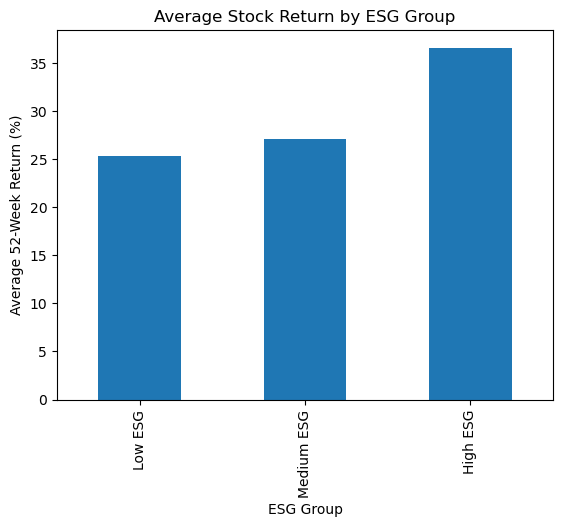

In [135]:
import matplotlib.pyplot as plt

esg_performance = df_stock.groupby(
    'ESG_Group'
)['52w_change price percent'].mean()

esg_performance.plot(kind='bar')

plt.title('Average Stock Return by ESG Group')
plt.xlabel('ESG Group')
plt.ylabel('Average 52-Week Return (%)')

plt.show()


# Visualized the relationship between ESG categories and average stock performance
# High ESG companies achieved the highest average stock returns

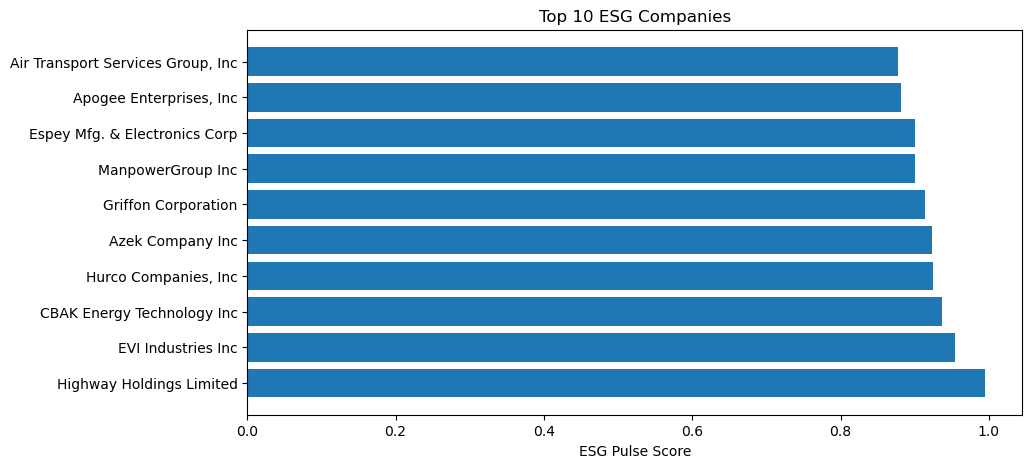

In [136]:
top_esg = df_stock.nlargest(
    10,
    'Company_ESG_pulse'
)

plt.figure(figsize=(10,5))

plt.barh(
    top_esg['Company_name'],
    top_esg['Company_ESG_pulse']
)

plt.title('Top 10 ESG Companies')
plt.xlabel('ESG Pulse Score')

plt.show()

# Identified and visualized the highest ESG-performing companies


In [137]:
subindustry_esg = df_stock.groupby(
    'gicSubindustry'
).agg(
    avg_esg=('Company_ESG_pulse','mean'),
    company_count=('Company_name','count')
)

subindustry_esg = subindustry_esg[
    subindustry_esg['company_count'] >= 10
]

subindustry_esg = subindustry_esg.sort_values(
    'avg_esg',
    ascending=False
)

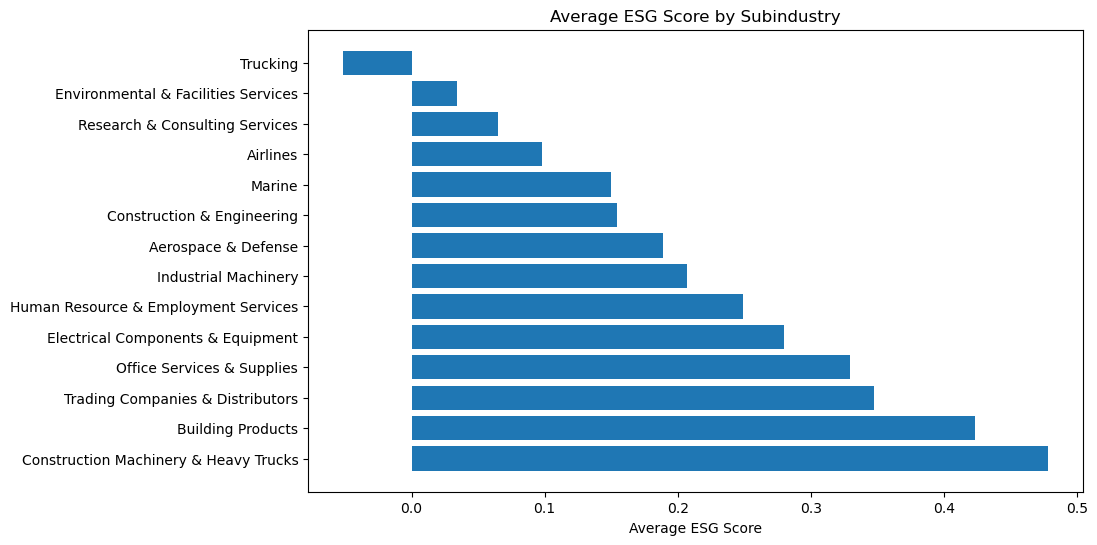

In [138]:
plt.figure(figsize=(10,6))

plt.barh(
    subindustry_esg.index,
    subindustry_esg['avg_esg']
)

plt.title('Average ESG Score by Subindustry')
plt.xlabel('Average ESG Score')

plt.show()


# Compared ESG performance across subindustries with sufficient representation

In [139]:
# retrive all companies
api_data = []

for symbol in df_stock['Symbol'].dropna().unique():

    try:
        ticker = yf.Ticker(symbol)

        api_data.append({
            'Symbol': symbol,
            'Current_Price': ticker.fast_info.get('lastPrice'),
            'Market_Cap_API': ticker.info.get('marketCap')
        })

        print(f"Success: {symbol}")

    except Exception as e:
        print(f"Failed: {symbol}")

Success: MMM
Success: AOS
Success: AAON
Success: AIR
Success: ABM
Success: ACCO
Success: ADT
Success: ACM
Success: AGCO
Success: AME
Success: AXR


$ARC: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ARC: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")


Failed: ARC


$ARCW: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$ARCW: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ASGN: possibly delisted; no price data found  (period=5d)


Failed: ARCW
Success: ASGN


...

Failed: VVI
Success: VTSI
Success: VIRC
Success: SPCE
Success: GWW
Success: WCC
Success: WNC
Success: WAB
Success: WCN
Success: WM
Success: WTS
Success: WHLM


$WLMS: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$WLMS: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")


Failed: WLMS
Success: WLFC
Success: WSC
Success: XPO
Success: XYL
Success: YRIV
Success: YAYO


$YELL: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$YELL: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")


Failed: YELL
Success: ZIM
Success: ZTO
Success: NVT
Success: RTNB


Financial data was successfully retrieved for the majority of companies in the dataset, while some records could not be matched due to ticker changes, delistings, mergers and acquisitions, or unavailable market data.

In [140]:
len(api_df)

5

In [141]:
len(df_stock)

388

In [142]:
len(api_df)

5

In [143]:
# API success rate
(len(api_df) / len(df_stock)) * 100

1.2886597938144329

In [144]:
api_df.head()

,Symbol,Current_Price,Market_Cap
0,MMM,158.32,82574532608
1,AOS,59.08,8142915584
2,AAON,127.19,10418351104
3,AIR,129.01,5129988096
4,ABM,45.93,2690621952


In [145]:
api_df = pd.DataFrame(api_data)

api_df.head()

,Symbol,Current_Price,Market_Cap_API
0,MMM,158.320007,8.257453e+10
1,AOS,59.080002,8.142916e+09
2,AAON,127.190002,1.041835e+10
3,AIR,129.009995,5.129988e+09
4,ABM,45.930000,2.690622e+09


In [146]:
len(api_df)

326

# Retrieved live market data for 326 companies using the Yahoo Finance API
# API match rate: 84.02%
# Unmatched records are likely due to delistings, mergers, acquisitions, or ticker changes
# Successfully enriched the historical ESG dataset with current market information

In [147]:
df_enriched = df_stock.merge(
    api_df,
    on='Symbol',
    how='left'
)

In [148]:
df_enriched.head()

,Company_name,Symbol,gicSubindustry,Company_ESG_pulse,Market Cap,Volume,52w_change price percent,ESG_Group,Current_Price,Market_Cap_API
0,3M Company,MMM,Industrial Conglomerates,-0.083992,5.096457e+10,2024694.0,-10.83,Low ESG,158.320007,8.257453e+10
1,A. O. Smith Corporation,AOS,Building Products,0.251170,1.256457e+10,552008.0,29.49,Medium ESG,59.080002,8.142916e+09
2,"AAON, Inc",AAON,Building Products,0.739143,NaN,NaN,-10.51,High ESG,127.190002,1.041835e+10
3,AAR Corp,AIR,Aerospace & Defense,0.588800,2.186558e+09,174582.0,12.26,High ESG,129.009995,5.129988e+09
4,ABM Industries Incorporated,ABM,Environmental & Facilities Services,0.482884,2.705078e+09,149678.0,-1.57,High ESG,45.930000,2.690622e+09


In [149]:
df_enriched.to_csv(
    "/Users/malynnburanawichian/Downloads/enriched_esg_dataset.csv",
    index=False
)

In [157]:
df_stock.groupby('ESG_Group')['Company_ESG_pulse'].agg(
    ['min', 'max', 'mean', 'count']
)

/var/folders/k6/v97pgdpx3ss61r9kylwxkkzh0000gn/T/ipykernel_16589/1420156500.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stock.groupby('ESG_Group')['Company_ESG_pulse'].agg(


,min,max,mean,count
ESG_Group,,,,
Low ESG,-0.971600,0.000000,-0.180931,146
Medium ESG,0.005737,0.424877,0.251291,113
High ESG,0.426000,0.995400,0.634727,129


In [155]:
import os

print(os.listdir())

['.config', 'Music', '.copilot', '.mysqlsh-wb', 'Untitled1.ipynb', 'dumps', 'DA-final-proj-ESGratingandStockmarketperformance.ipynb', '.DS_Store', '.vscode-shared', '.CFUserTextEncoding', 'Untitled-1.ipynb', '.xonshrc', 'anaconda_projects', 'Untitled.ipynb', '.zshrc', '.local', 'Pictures', 'DA bootcamp', '.zprofile', 'Study + certs', '.zsh_history', '.ipython', 'payroll 2026', 'Desktop', 'Library', '.matplotlib', 'job requirements', 'API.py', 'Public', 'webscrapcities.ipynb', '.tcshrc', 'beautifulsoupchallenge1.ipynb', 'work', '.virtual_documents', '.anaconda', 'Movies', 'Applications', 'flights_api.ipynb', '.Trash', '.ipynb_checkpoints', '.jupyter', 'Documents', '.mysql_history', '.vscode', '.bash_profile', 'Downloads', '.continuum', 'weather_api.ipynb', 'Personal Docs CV etc', '.zsh_sessions', '.conda']


In [156]:
print(df.head())
print(df.columns.tolist())

   Unique_id Symbol             Company_name                 Exchange  \
0     190179    MMM               3M Company  New York Stock Exchange   
1     205868   JOBS               51job, Inc                   Nasdaq   
2     191323    AOS  A. O. Smith Corporation  New York Stock Exchange   
3     206373   AAON                AAON, Inc                   Nasdaq   
4     190905    AIR                 AAR Corp  New York Stock Exchange   

     gicSector                        gicSubindustry  Company_ESG_pulse  \
0  Industrials              Industrial Conglomerates          -0.083992   
1  Industrials  Human Resource & Employment Services           0.776978   
2  Industrials                     Building Products           0.251170   
3  Industrials                     Building Products           0.739143   
4  Industrials                   Aerospace & Defense           0.588800   

   ESG_beta   SNP  Sustainalytics  ... 52w_change price  \
0  0.010832  67.0            32.2  ...          -11

In [15]:
import pandas as pd

# Load file
df = pd.read_csv("esg_api_enriched_clean.csv")

# Create ESG Rank (1 = highest ESG score)
df["ESG_Rank"] = df["Company_ESG_pulse"].rank(
    ascending=False,
    method="dense"
).astype(int)

# Save updated file
df.to_csv("esg_api_enriched_clean.csv", index=False)

print("Done!")
print(df[["Company_name", "Company_ESG_pulse", "ESG_Rank"]].head())

Done!
                  Company_name  Company_ESG_pulse  ESG_Rank
0                   3M Company          -0.083992       261
1      A. O. Smith Corporation           0.251170       192
2                    AAON, Inc           0.739143        34
3                     AAR Corp           0.588800        67
4  ABM Industries Incorporated           0.482884       104


In [16]:
print(df["ESG_Rank"].min())
print(df["ESG_Rank"].max())

1
324


In [17]:
df.to_csv("esg_api_enriched_ranked.csv", index=False)

In [19]:
test = pd.read_csv("esg_api_enriched_ranked.csv")

print(test.columns.tolist())

['Company_name', 'Symbol', 'gicSubindustry', 'Company_ESG_pulse', 'Market_Cap', 'Volume', 'Return_52w_Percent', 'ESG_Group', 'Current_Price', 'Market_Cap_API', 'ESG_Rank']
